In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Downloading the datasets
!wget -O CO2_Emissions.csv https://raw.githubusercontent.com/SrinathShree/co2-emission/refs/heads/main/Datasets/CO2_Emissions.csv

--2026-03-23 19:04:43--  https://raw.githubusercontent.com/SrinathShree/co2-emission/refs/heads/main/Datasets/CO2_Emissions.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 476091 (465K) [text/plain]
Saving to: ‘CO2_Emissions.csv’

CO2_Emissions.csv   100%[===================>] 464.93K  --.-KB/s    in 0.06s   

2026-03-23 19:04:43 (7.76 MB/s) - ‘CO2_Emissions.csv’ saved [476091/476091]



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1.	Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.**

In [4]:
df = pd.read_csv('CO2_Emissions.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

This dataset has the detailed information of cars like Make & Model, Engine charecteristics, Transmission types & other Vehicle specifications like mileage and how much CO2 is emitted from that car.

In [6]:
df.shape

(7385, 12)

In [7]:
df.isna().value_counts()

,,,,,,,,,,,,count
Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),
False,False,False,False,False,False,False,False,False,False,False,False,7385


As we can see above there are no missing values(na) in this dataset.

In [8]:
cat_columns = ['Make','Model','Vehicle Class','Transmission','Cylinders','Fuel Type']
cat_columns

['Make', 'Model', 'Vehicle Class', 'Transmission', 'Cylinders', 'Fuel Type']

In [9]:
num_columns = df.columns.difference(cat_columns).values
num_columns

array(['CO2 Emissions(g/km)', 'Engine Size(L)',
       'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)',
       'Fuel Consumption Hwy (L/100 km)'], dtype=object)

1. These are the Categorical columns in the data set --> ['Make', 'Model',
'Vehicle Class', 'Transmission', 'Fuel Type'].
2. These are the Numerical columns in the data set -->['CO2 Emissions(g/km)',    'Engine Size(L)','Fuel Consumption City (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'Fuel Consumption Hwy (L/100 km)'].

3. Cylinders is a categorical column with numerical values in it.
4. CO2 Emissions(g/km) is the target column in the dataset.

Performing pairplot on all the numerical columns & the target variable to understand the relation between these features.

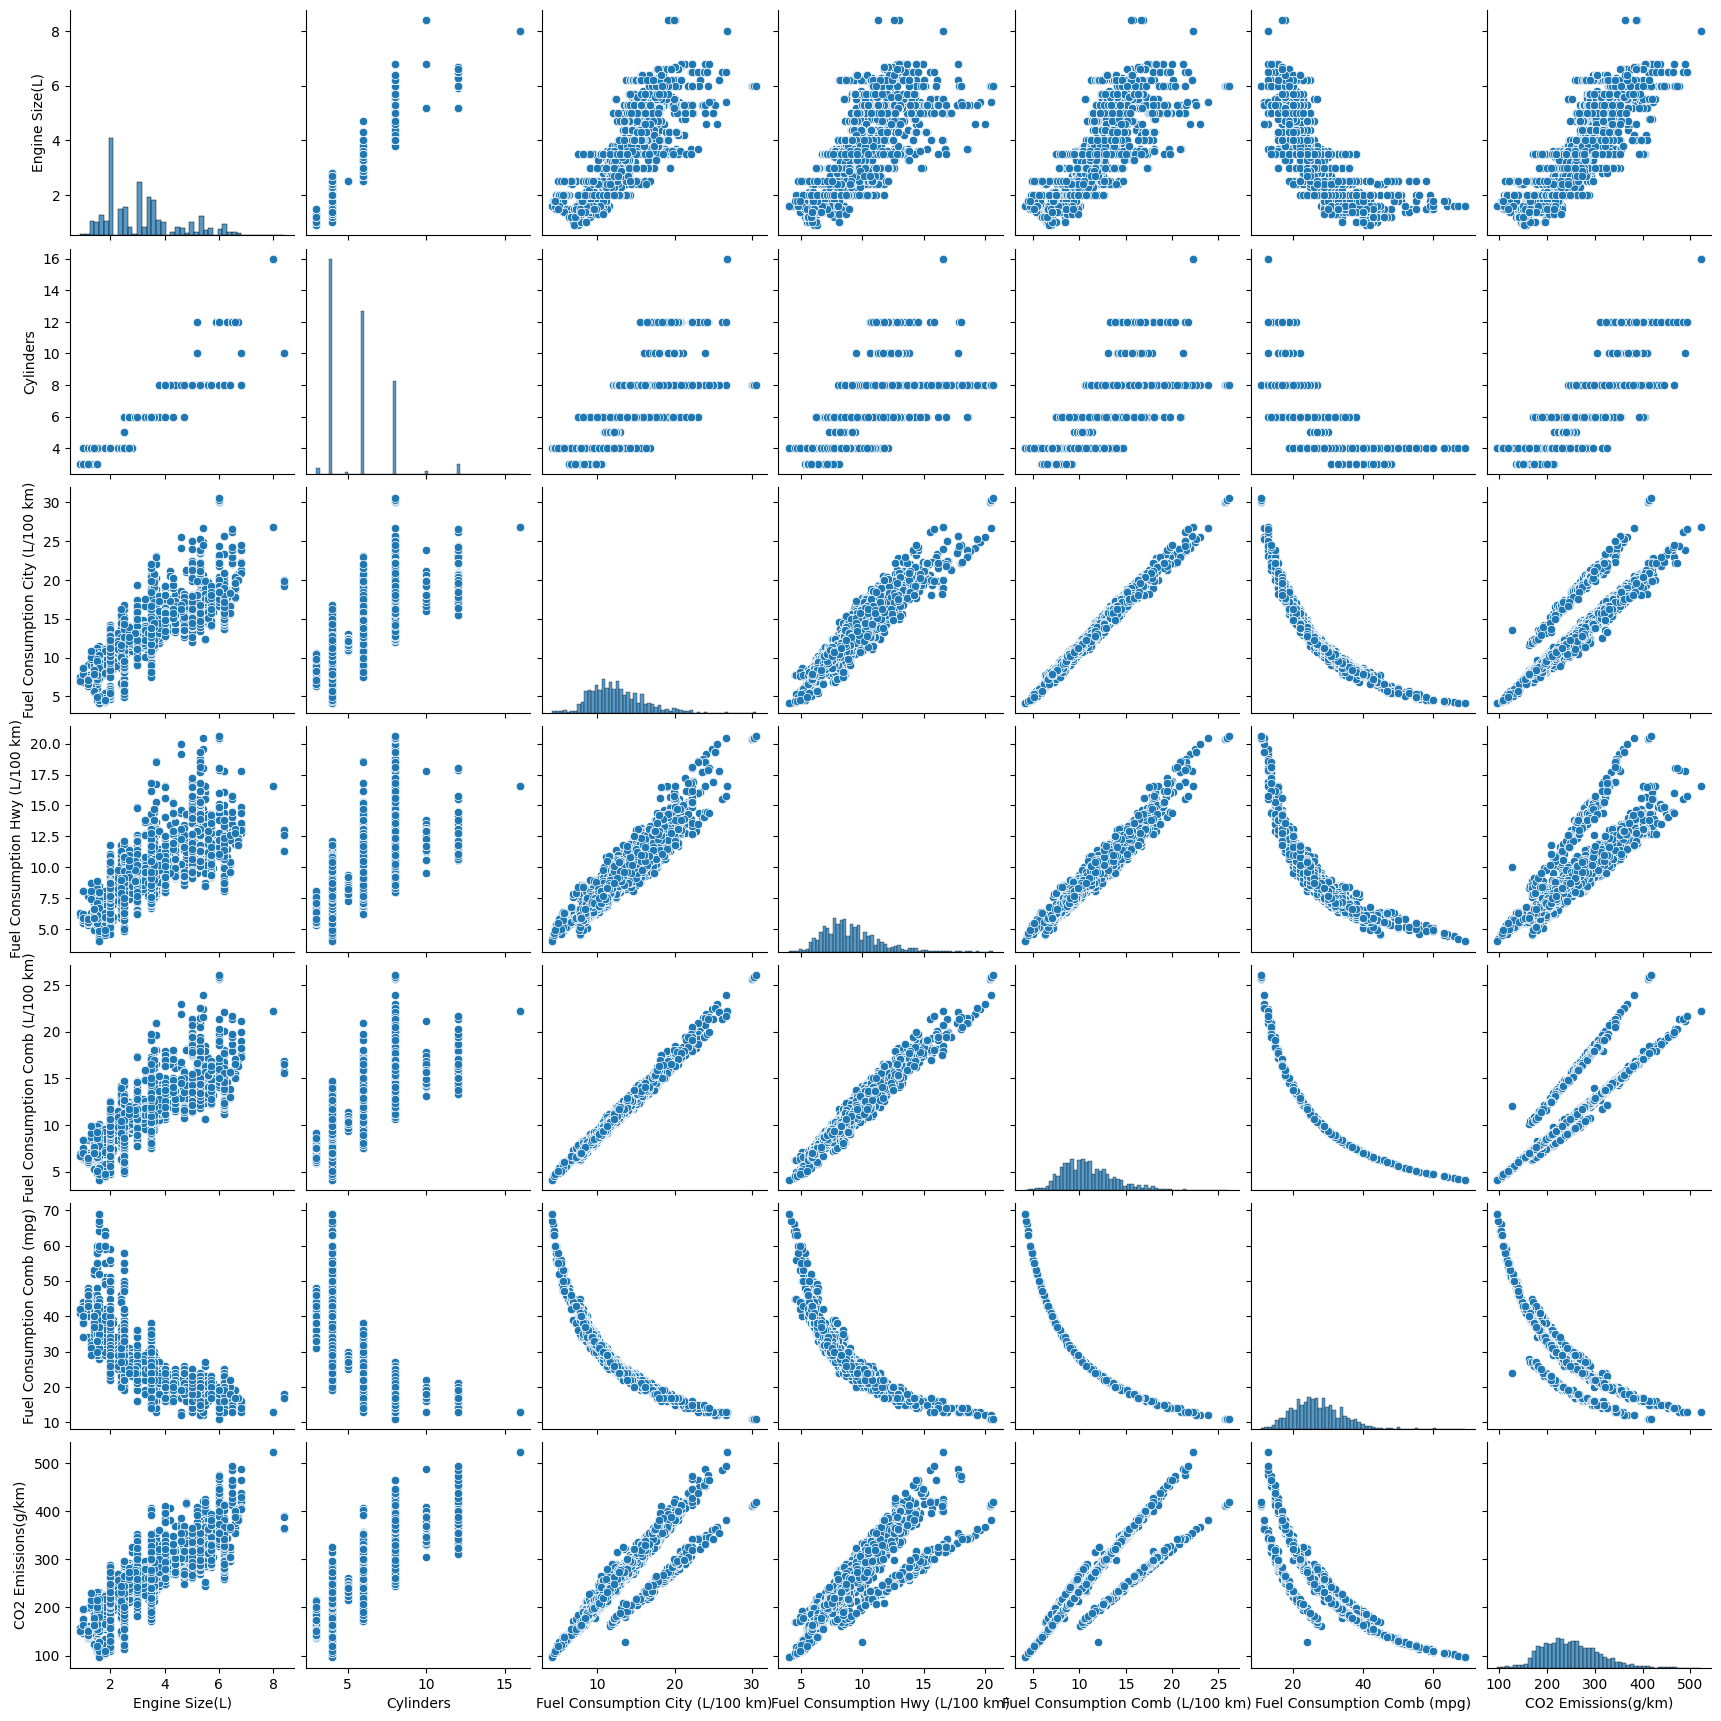

In [10]:
sns.pairplot(df)

Below are the observations from Pairplot

*   As we can see above 'CO2 Emissions(g/km)' has high correlation with Engine Size, 'Cylinders','Engine Size(L)', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)' features i.e., when these feature value increases then 'CO2 Emissions(g/km)' increases & viceversa.
*   'CO2 Emissions(g/km)' has negative correlation with 'Fuel Consumption Comb (mpg)' feature i.e., when Fuel Consumption Comb (mpg) increases CO2 Emissions(g/km) decreases and viceversa.
*   There is high correlation between 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)' & 'Fuel Consumption Comb (L/100 km)' & it is very much linear with positive slope i.e., when 'Fuel Consumption City (L/100 km)'/'Fuel Consumption Hwy (L/100 km)' increases then 'Fuel Consumption Comb (L/100 km)' is also increasing & viceversa.
*   There is high positive correlation between 'Cylinders' & 'Engine Size(L) features as well.



**2.	Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.**

In [11]:
df.groupby(['Make','Model','Fuel Type'])['CO2 Emissions(g/km)'].mean().reset_index().head(5)

,Make,Model,Fuel Type,CO2 Emissions(g/km)
0,ACURA,ILX,Z,199.222222
1,ACURA,ILX HYBRID,Z,138.000000
2,ACURA,MDX 4WD,Z,255.000000
3,ACURA,MDX HYBRID AWD,Z,210.000000
4,ACURA,MDX Hybrid AWD,Z,210.000000


In [12]:
df['Model'].nunique()

2053

In [13]:
df[df['Model'].isin(['MDX Hybrid AWD','MDX HYBRID AWD'])]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3316,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
4374,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
5457,ACURA,MDX Hybrid AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
6506,ACURA,MDX Hybrid AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210


As we can see above in the Model column, For Some Cars model is in upper case & for same car model is in lower case as well.Ex:- ACURA	MDX HYBRID AWD & ACURA	MDX Hybrid AWD. We see this inconsistency in the data.
So, let's convert all the data in Model column to upper case. This will remove inconsistency in the data.

In [14]:
df['Model'] = df['Model'].str.upper()

In [15]:
df[df['Model'].isin(['MDX Hybrid AWD','MDX HYBRID AWD','TACOMA 4WD D-CAB TRD OFF-ROAD/PRO'])]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3316,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
4374,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
5457,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
6506,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
7355,TOYOTA,TACOMA 4WD D-CAB TRD OFF-ROAD/PRO,PICKUP TRUCK - SMALL,3.5,6,M6,X,13.8,11.7,12.9,22,300


In [16]:
df['Model'].nunique()

1596

In [17]:
df['Vehicle Class'].unique()

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

Vehicle Class column has extra spaces in the text 'SUV - SMALL' we can remove them and make it consistent. For Ex:- Converting 'SUV - SMALL' --> 'SUVSMALL'

In [18]:
df['Vehicle Class'] = df['Vehicle Class'].str.replace(' ','').str.replace('-','')
df['Vehicle Class'].unique()

array(['COMPACT', 'SUVSMALL', 'MIDSIZE', 'TWOSEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULLSIZE', 'STATIONWAGONSMALL', 'SUVSTANDARD',
       'VANCARGO', 'VANPASSENGER', 'PICKUPTRUCKSTANDARD', 'MINIVAN',
       'SPECIALPURPOSEVEHICLE', 'STATIONWAGONMIDSIZE', 'PICKUPTRUCKSMALL'],
      dtype=object)

In [19]:
df.isna().value_counts()

,,,,,,,,,,,,count
Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),
False,False,False,False,False,False,False,False,False,False,False,False,7385


As we can see above there are no missing values in the dataset.

In [20]:
df.duplicated().value_counts()

,count
False,5991
True,1394


As we can see there are 1394 duplicated rows in dataset. Will remove these rows below.

In [21]:
df = df.drop_duplicates(keep = 'first').reset_index(drop = True)
df.duplicated().value_counts()

,count
False,5991


In [22]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000
mean,3.173043,5.633784,12.650075,9.091320,11.049224,27.329494,251.638124
std,1.365751,1.851161,3.560977,2.293336,2.957762,7.187305,59.246929
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.800000,6.000000,14.700000,10.300000,12.700000,32.000000,290.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


*   Remove Anomolies or outliers if any.
*   We need to split this data set to categorical & numerical columns and perform the encoding on categorical columns.
*   Standardize the numerical column data.
*   Remove the highly correlated & irrelevant features from the dataset.
*   Seperate the input features & target feature, Perform train_test_split on the Standardized data & split into train, validation & test data..




**3.	Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.**

<Axes: >

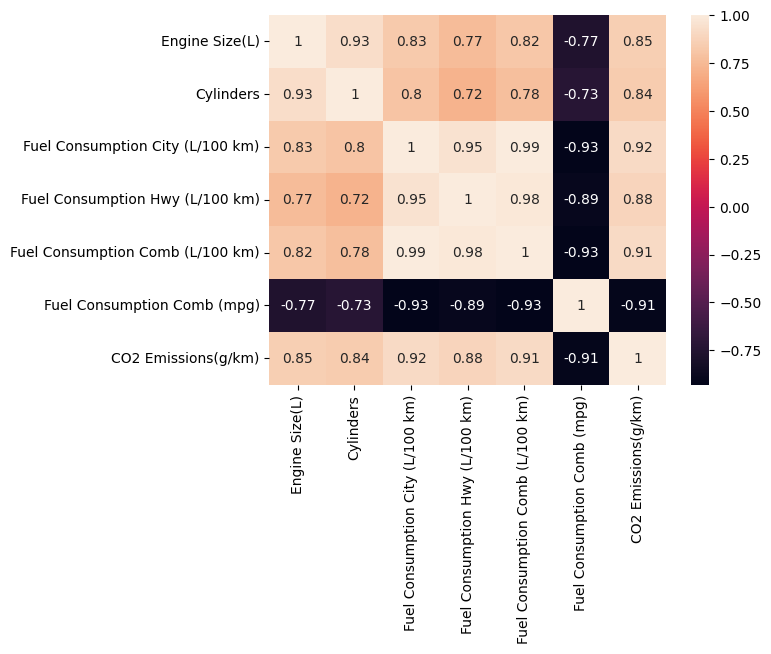

In [23]:
df_corr = df[df.columns[df.dtypes.values != 'O']].corr()
sns.heatmap(df_corr, annot= True)

*   As we can see above 'CO2 Emissions(g/km)' has high correlation with Engine Size, 'Cylinders','Engine Size(L)', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)' features i.e., when these feature value increases then 'CO2 Emissions(g/km)' increases & viceversa.
*   'CO2 Emissions(g/km)' has negative correlation with 'Fuel Consumption Comb (mpg)' feature i.e., when Fuel Consumption Comb (mpg) increases CO2 Emissions(g/km) decreases and viceversa.

**4.	Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.**

In [24]:
X = df.drop(columns= 'CO2 Emissions(g/km)')
Y = df['CO2 Emissions(g/km)']

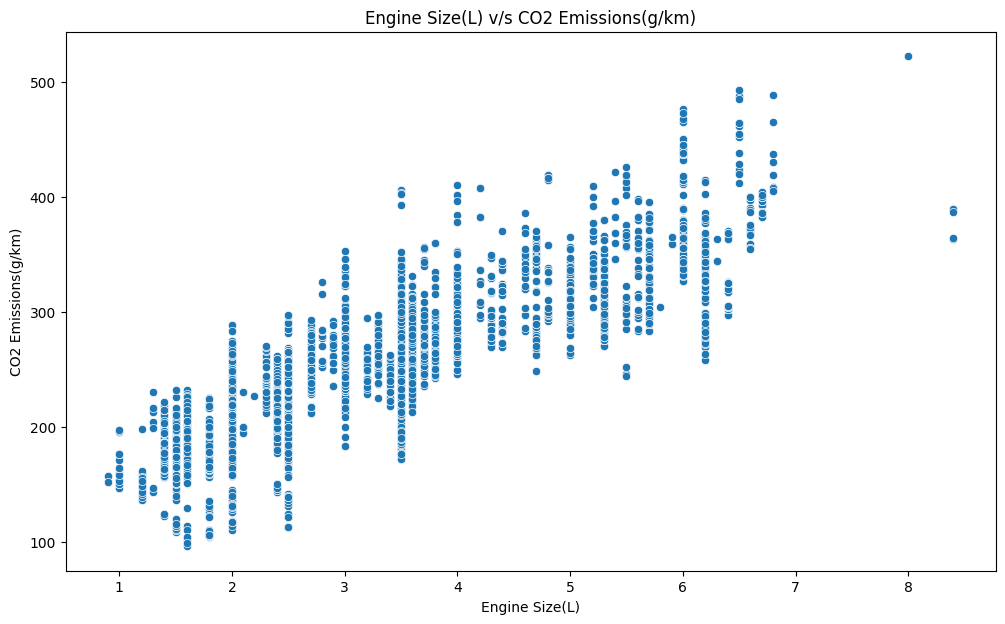

In [25]:
plt.figure(figsize = (12,7))
sns.scatterplot(x = X['Engine Size(L)'], y = Y)
plt.title('Engine Size(L) v/s CO2 Emissions(g/km)')
plt.show()


In the above plot as we can see as increase in Engine Size, the CO2 Emissions are also increasing. Highend Engine cars produce more CO2 Emissions.

Also, we can see 1 datapoints as an outliers where engine size is more than 8L & CO2 Emission is more than 500 gm/KM. Let's find it below.

In [26]:
df[(df['Engine Size(L)'] >= 8) & (df['CO2 Emissions(g/km)'] > 500)]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
4199,BUGATTI,CHIRON,TWOSEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522


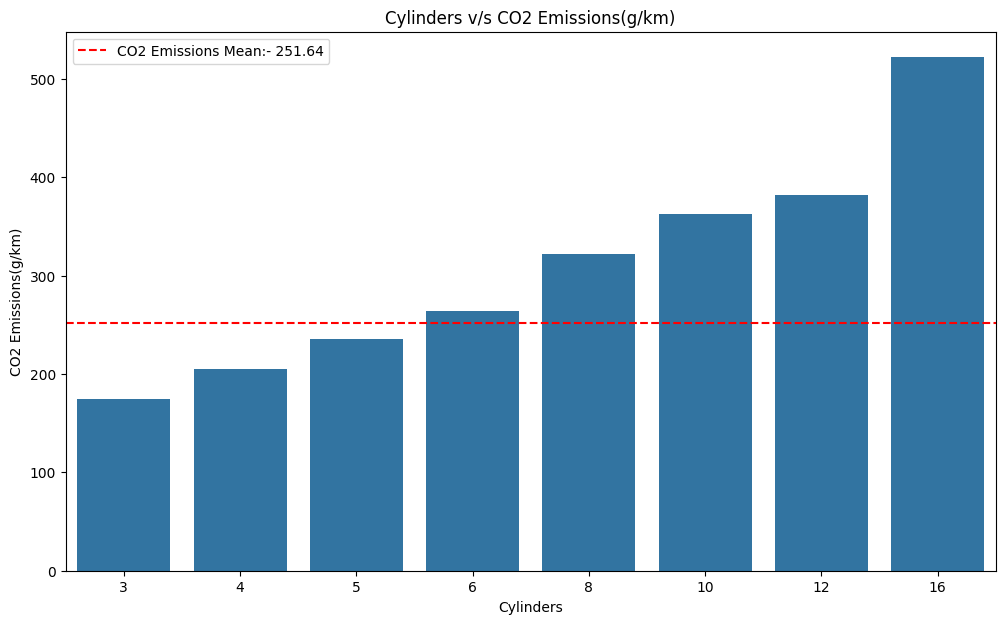

In [27]:
df_avg_emission_per_cylinder = df.groupby('Cylinders')['CO2 Emissions(g/km)'].mean().reset_index()
plt.figure(figsize = (12,7))
sns.barplot(x = df_avg_emission_per_cylinder['Cylinders'], y = df_avg_emission_per_cylinder['CO2 Emissions(g/km)'])
plt.axhline(y = df['CO2 Emissions(g/km)'].mean(), linestyle = '--', color = 'r',
            label = f'CO2 Emissions Mean:- {round(df['CO2 Emissions(g/km)'].mean(),2)}')
plt.title('Cylinders v/s CO2 Emissions(g/km)')
plt.legend()
plt.show()

* As we can see above as the No. Of Cylinders increases the CO2 Emissions are also increasing.
* Engines with Cylinders - {8,10,12,16} are above the cylinders feature average mean and they will cause high emissions.


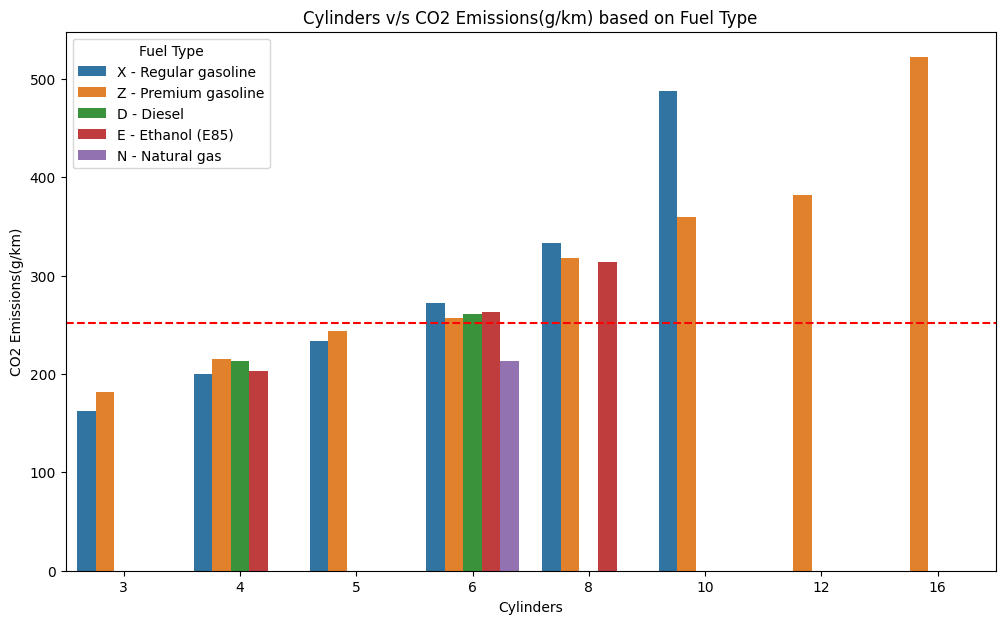

In [28]:
df_avg_emission_per_cylinder_fuel_type = df.groupby(['Cylinders','Fuel Type'])['CO2 Emissions(g/km)'].mean().reset_index()
plt.figure(figsize = (12,7))
ax = sns.barplot(x = df_avg_emission_per_cylinder_fuel_type['Cylinders'], y = df_avg_emission_per_cylinder_fuel_type['CO2 Emissions(g/km)'],
            hue = df_avg_emission_per_cylinder_fuel_type['Fuel Type'])
plt.axhline(y = df['CO2 Emissions(g/km)'].mean(), linestyle = '--', color = 'r',
            label = f'CO2 Emissions Mean:- {df['CO2 Emissions(g/km)'].mean()}')
plt.title('Cylinders v/s CO2 Emissions(g/km) based on Fuel Type')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,
          labels=["X - Regular gasoline", "Z - Premium gasoline", "D - Diesel", "E - Ethanol (E85)", "N - Natural gas"],
          title="Fuel Type")
plt.show()

* As we can see above, For the 10 cylinder engine the fuel type X - Regular gasoline produces more CO2 Emissions than the Z - Premium gasoline.
* Also, 12 & 16 Cylinder engines are built for fuel type Z - Premium gasoline produces less CO2 Emissions compared to X - Regular gasoline.


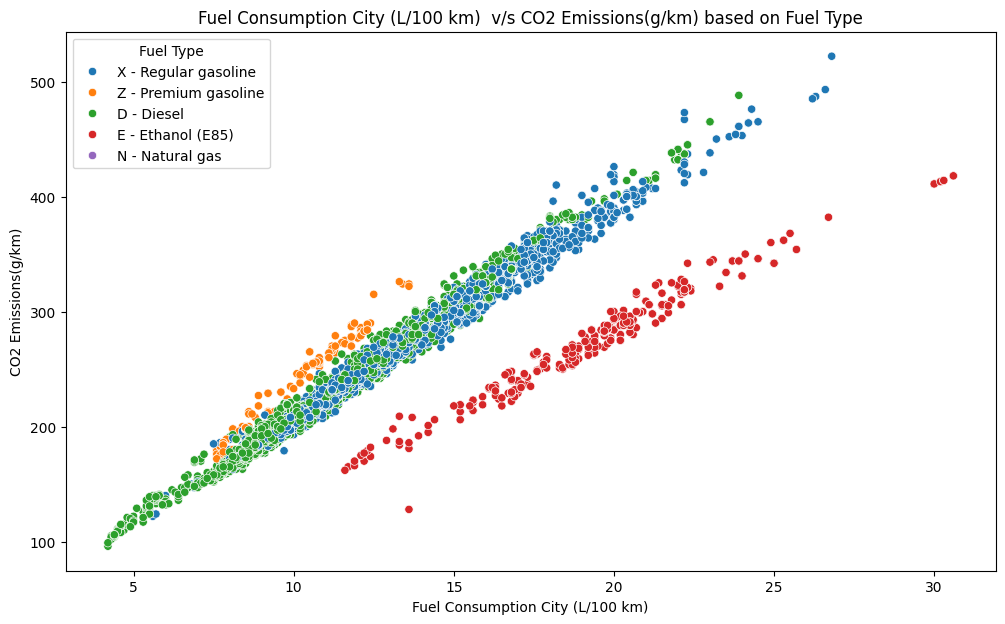

In [29]:
plt.figure(figsize = (12,7))
ax = sns.scatterplot(x = X['Fuel Consumption City (L/100 km)'], y = Y, hue = X['Fuel Type'])
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles,
           labels = ["X - Regular gasoline", "Z - Premium gasoline", "D - Diesel", "E - Ethanol (E85)", "N - Natural gas"],
           title = 'Fuel Type')
plt.title('Fuel Consumption City (L/100 km)  v/s CO2 Emissions(g/km) based on Fuel Type')
plt.show()

* As we can see in the above plot as the Fuel Consumption City (L/100 km) increases the CO2 Emission will also increase
* We can see the data is fragmented in 3 parts, but follows an increasing trend in all these parts.
* These parts are formed based on fuel type, with E - Ethanol (E85), Z - Premium gasoline seperated from the other fuel types.
* X - Regular gasoline, D - Diesel & N - Natural gas are more collided

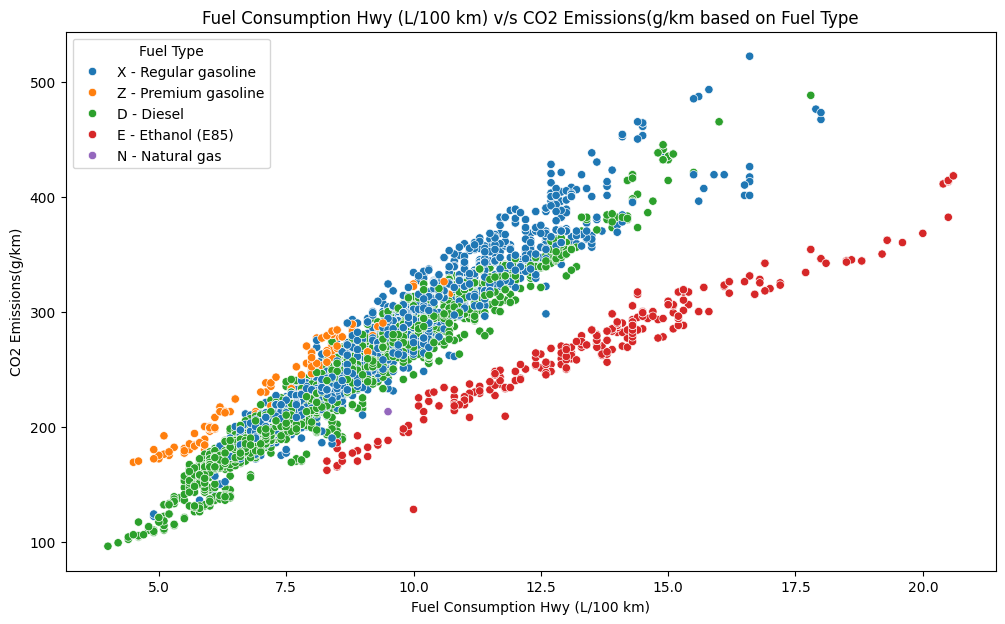

In [30]:
plt.figure(figsize = (12,7))
ax = sns.scatterplot(x = X['Fuel Consumption Hwy (L/100 km)'], y = Y, hue = X['Fuel Type'])
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles, labels = ["X - Regular gasoline", "Z - Premium gasoline", "D - Diesel", "E - Ethanol (E85)", "N - Natural gas"],
           title = 'Fuel Type')
plt.title('Fuel Consumption Hwy (L/100 km) v/s CO2 Emissions(g/km based on Fuel Type')
plt.show()

* As we can see in the above plot as the Fuel Consumption Hwy (L/100 km) increases the CO2 Emission will also increase.
* We can see the data is fragmented in 3 parts, but follows an increasing trend in al these parts.
* These parts are formed based on fuel type, with E - Ethanol (E85), Z - Premium gasoline seperated from the other fuel types.
* X - Regular gasoline, D - Diesel & N - Natural gas are colliding more in the beginning of the plot but as the Fuel Consumption increases the X - Regular gasoline is moving away from D - Diesel.
* Z - Premium gasoline is also more spreading out into X - Regular gasoline as in highways the fuel consumption will be when compared to city.

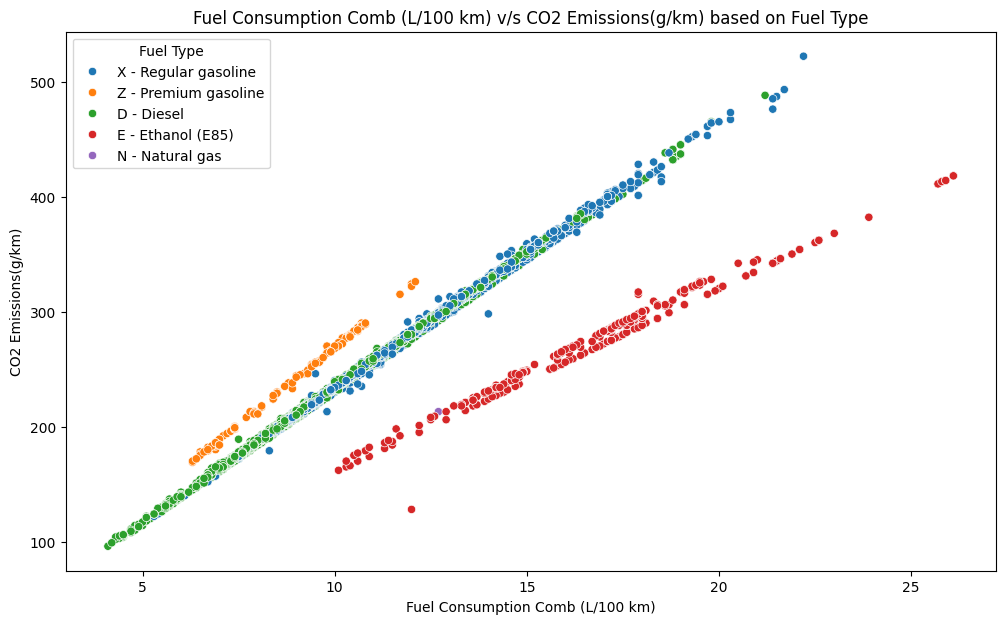

In [31]:
plt.figure(figsize = (12,7))
ax = sns.scatterplot(x = X['Fuel Consumption Comb (L/100 km)'], y = Y, hue = X['Fuel Type'])
plt.title('Fuel Consumption Comb (L/100 km) v/s CO2 Emissions(g/km) based on Fuel Type')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles,
           labels = ["X - Regular gasoline", "Z - Premium gasoline", "D - Diesel", "E - Ethanol (E85)", "N - Natural gas"],
           title = 'Fuel Type')
plt.show()

* As we can see in the above plot as the Fuel Consumption Comb (L/100 km) increases the CO2 Emission will also increase.
* We can see the data is fragmented in 3 parts, but follows an increasing trend in all these parts.
* These parts are formed based on fuel type, with E - Ethanol (E85), Z - Premium gasoline seperated from the other fuel types. Here the seperation is more clear as it's the fuel consumption combination(55% city, 45% hwy).
* X - Regular gasoline, D - Diesel & N - Natural gas are very much close and it follows the same trend from beginning to the end. It means these 3 fuel types are very much correlated.
* Also, i see few outlier wher Emission is >= 480 for X - Regular gasoline & Emission is < 100 for E - Ethanol (E85).

In [32]:
df[(df['Fuel Type'] == 'E') & (df['CO2 Emissions(g/km)'] < 150)]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3817,MERCEDES-BENZ,GLA 250 4MATIC,SUVSMALL,2.0,4,AS7,E,13.6,10.0,12.0,24,128


In [33]:
df[(df['Fuel Type'] == 'X') & (df['CO2 Emissions(g/km)'] > 480)]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
349,FORD,E350 WAGON,VANPASSENGER,6.8,10,A5,X,23.9,17.8,21.2,13,488


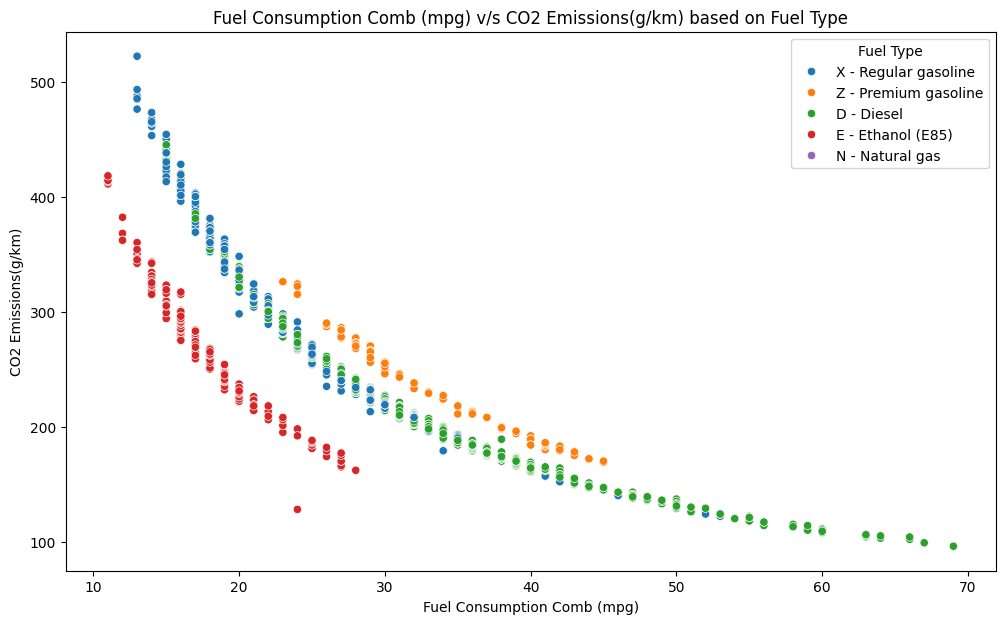

In [34]:
plt.figure(figsize = (12,7))
sns.scatterplot(x = X['Fuel Consumption Comb (mpg)'], y = Y, hue = X['Fuel Type'])
plt.title('Fuel Consumption Comb (mpg) v/s CO2 Emissions(g/km) based on Fuel Type')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles, labels = ["X - Regular gasoline", "Z - Premium gasoline", "D - Diesel", "E - Ethanol (E85)", "N - Natural gas"],
           title = 'Fuel Type')
plt.show()

* As we can see in the above plot as the Fuel Consumption Comb (mpg)  increases the CO2 Emission decreases.
* We can see the data is fragmented in 3 parts, but follows the decreasing trend in all these parts.
* These parts are formed based on fuel type with E - Ethanol (E85), Z - Premium gasoline seperated from the other fuel types. Here the seperation is more clear as it's the fuel consumption combination(55% city, 45% hwy).
* X - Regular gasoline, D - Diesel & N - Natural gas are very much close and it follows the same trend from beginning to the end. It means these 3 fuel types are very much correlated.
* The data in all the other fuel_consumption features form a linear line but here it forms a curved line.

Although the question asked to plot the numerical features with CO2 Emissions. I did plot them as asked, but seperated the data based on fuel type feature as it helped us in recognizing the hidden patterns in the data.

**5.	Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.**

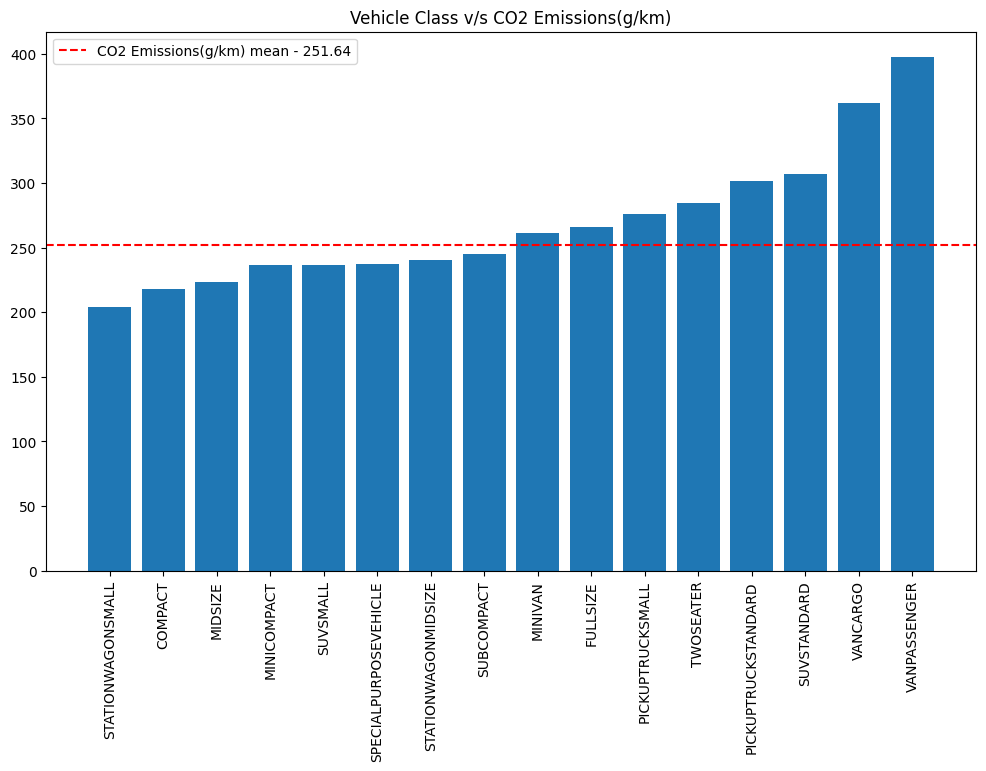

In [35]:
df_avg_emission_per_vehicle_class = df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().reset_index()
df_avg_emission_per_vehicle_class = df_avg_emission_per_vehicle_class.sort_values(by = 'CO2 Emissions(g/km)')
plt.figure(figsize = (12,7))
plt.bar(df_avg_emission_per_vehicle_class['Vehicle Class'],
        df_avg_emission_per_vehicle_class['CO2 Emissions(g/km)'])
plt.axhline(y = df['CO2 Emissions(g/km)'].mean(), linestyle = '--', color = 'r',
            label = f'CO2 Emissions(g/km) mean - {round(df['CO2 Emissions(g/km)'].mean(),2)}')
plt.legend()
plt.xticks(rotation = 90)
plt.title('Vehicle Class v/s CO2 Emissions(g/km)')
plt.show()

* As we can see above VANPASSENGER category is emitting more CO2 than all the other categories.
* STATIONWAGONSMALL is emitting less fuel when compared with all the other categories.
* Let's compare the CO2 Emissions based on fuel type as well.

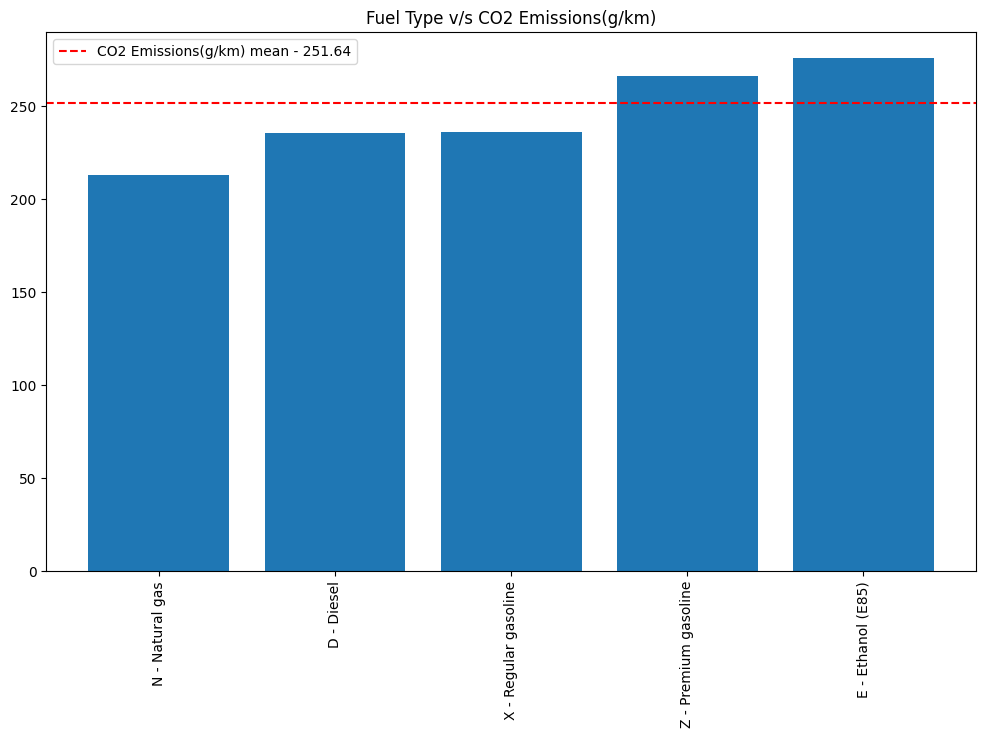

In [36]:
df_avg_emission_per_fuel_type = df.groupby('Fuel Type')['CO2 Emissions(g/km)'].mean().reset_index()
df_avg_emission_per_fuel_type = df_avg_emission_per_fuel_type.sort_values(by = 'CO2 Emissions(g/km)')
plt.figure(figsize = (12,7))
plt.bar(df_avg_emission_per_fuel_type['Fuel Type'],
        df_avg_emission_per_fuel_type['CO2 Emissions(g/km)'])
plt.axhline(y = df['CO2 Emissions(g/km)'].mean(), linestyle = '--', color = 'r',
            label = f'CO2 Emissions(g/km) mean - {round(df['CO2 Emissions(g/km)'].mean(),2)}')
plt.legend()
plt.xticks(['N','D','X','Z','E'],rotation = 90,
           labels= ["N - Natural gas","D - Diesel","X - Regular gasoline","Z - Premium gasoline","E - Ethanol (E85)"])
plt.title('Fuel Type v/s CO2 Emissions(g/km)')
plt.show()

* As we can see above the CO2 emissions from all these fuel types are closer to the mean CO2 emission of the entire dataset.
* Vehicles that run on N - Natural gas engines emit the lowest while Ethanol(E85) engine emit the highest CO2.
* Let compare vehicle class with co2 emissions based on fuel type...

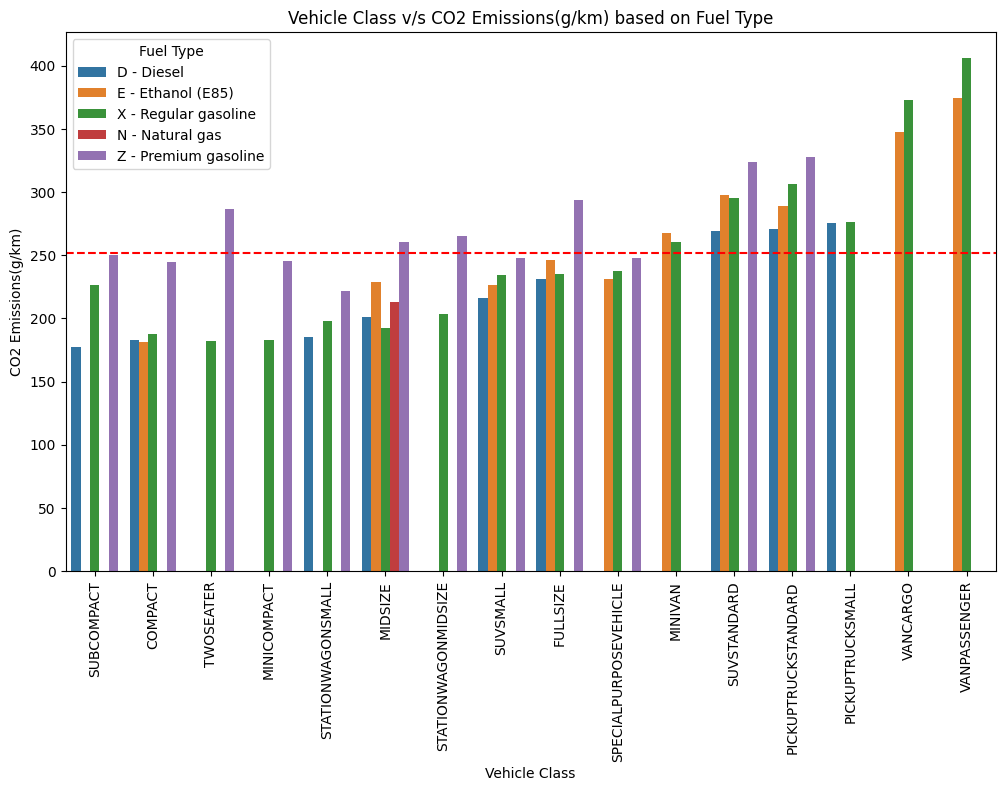

In [37]:
df_avg_emission_per_vehicle_class_fuel_type = df.groupby(['Vehicle Class','Fuel Type'])['CO2 Emissions(g/km)'].mean().reset_index()
df_avg_emission_per_vehicle_class_fuel_type = df_avg_emission_per_vehicle_class_fuel_type.sort_values(by = 'CO2 Emissions(g/km)')
plt.figure(figsize = (12,7))
ax = sns.barplot(x = 'Vehicle Class', y = 'CO2 Emissions(g/km)', data = df_avg_emission_per_vehicle_class_fuel_type,
        hue = 'Fuel Type')
plt.axhline(y = df['CO2 Emissions(g/km)'].mean(), linestyle = '--', color = 'r',
            label = f'CO2 Emissions(g/km) mean - {round(df['CO2 Emissions(g/km)'].mean(),2)}')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles, labels = ["D - Diesel","E - Ethanol (E85)","X - Regular gasoline","N - Natural gas","Z - Premium gasoline"],
           title = 'Fuel Type')
#plt.legend()
plt.xticks(rotation = 90)
plt.title('Vehicle Class v/s CO2 Emissions(g/km) based on Fuel Type')
plt.show()

* As we can see above the SUBCOMPACT emits the lowest CO2 & VANPASSENGER emits the highest.
* Ethanol & Regular Gasoline engines emit the highest CO2.
* Premium gasoline engines emit more CO2 than the average CO2 emission in almost all the vehicle categories.
* Only MIDSIZE segment has vehicles with all the fuel types.
* VAN Category Vehicles only uses Ethanol & Regular Gasoline engines
* Ethonal emits less CO2  when compared to other Fuel types in the same Category.

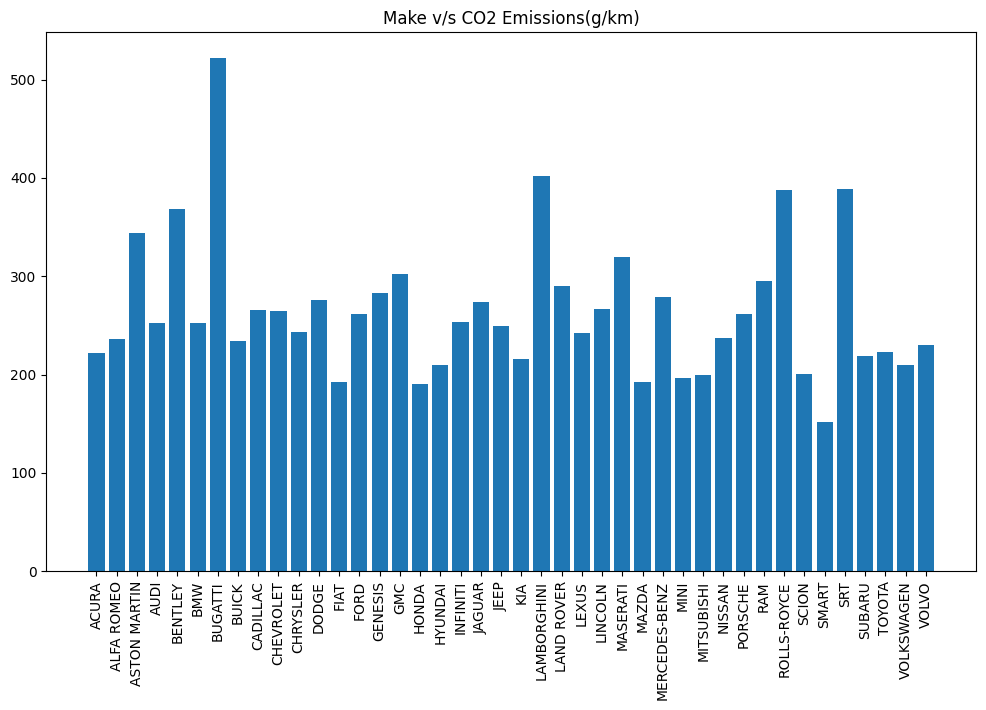

In [38]:
plt.figure(figsize = (12,7))
plt.bar(df.groupby('Make')['CO2 Emissions(g/km)'].mean().reset_index()['Make'],
        df.groupby('Make')['CO2 Emissions(g/km)'].mean().reset_index()['CO2 Emissions(g/km)'])
plt.title('Make v/s CO2 Emissions(g/km)')
plt.xticks(rotation = 90)
plt.show()

Text(0.5, 1.0, 'Transmission v/s CO2 Emissions(g/km)')

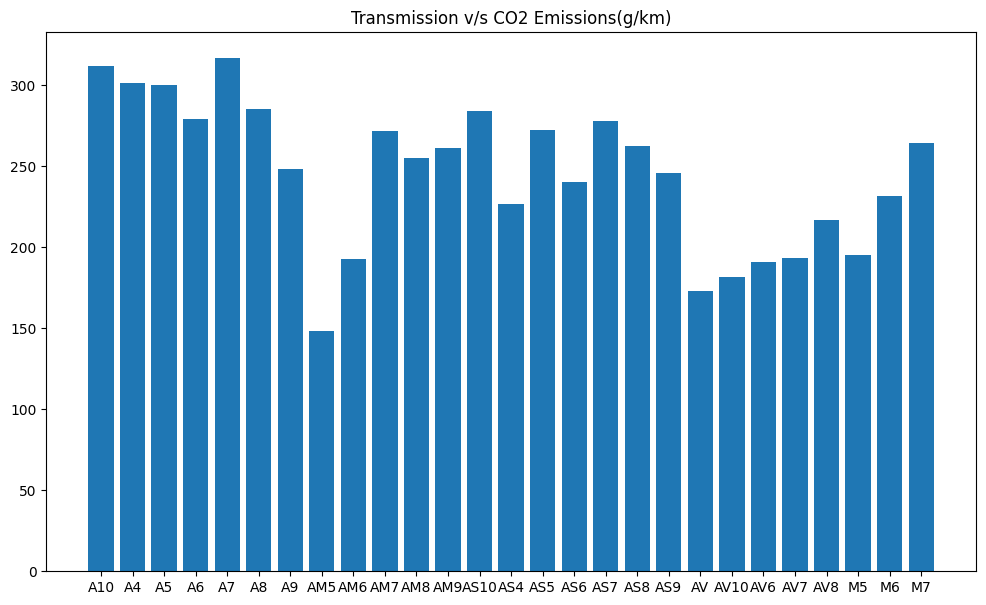

In [39]:
plt.figure(figsize = (12,7))
plt.bar(df.groupby('Transmission')['CO2 Emissions(g/km)'].mean().reset_index()['Transmission'],
        df.groupby('Transmission')['CO2 Emissions(g/km)'].mean().reset_index()['CO2 Emissions(g/km)'])
plt.title('Transmission v/s CO2 Emissions(g/km)')

**6.	Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.**

* To find the vehicles that produce unusually high or low emissions within the similar charecteristics, Grouped all the vehicle charecteristics('Engine Size(L)','Cylinders','Fuel Type','Transmission') on the data frame and performed the describe() operation on CO2 Emissions to know how the data is distributed among the similar charecteristics.

In [40]:
df_grouped_by_vehicle_charecteristics = df.groupby(['Engine Size(L)','Cylinders','Fuel Type','Transmission'])
df_grouped_by_vehicle_charecteristics = df_grouped_by_vehicle_charecteristics['CO2 Emissions(g/km)'].describe()
df_grouped_by_vehicle_charecteristics = df_grouped_by_vehicle_charecteristics.sort_values(by = 'std', ascending = False)
df_grouped_by_vehicle_charecteristics.head(20)

count        mean  \
Engine Size(L) Cylinders Fuel Type Transmission                      
3.5            6         Z         AM7             8.0  293.375000   
6.0            12        Z         A7              4.0  380.750000   
2.0            4         E         AS7             2.0  163.000000   
6.2            8         Z         AS6             8.0  347.250000   
5.5            8         Z         AS7            44.0  332.000000   
                                   A7              6.0  350.166667   
6.2            8         Z         AS10            5.0  328.800000   
2.0            4         Z         M5              2.0  252.000000   
5.0            8         X         A6              3.0  314.333333   
4.0            8         Z         A7              9.0  296.888889   
6.0            12        Z         AS7            17.0  363.294118   
2.0            4         X         AV             54.0  173.055556   
1.6            4         X         AM6            14.0  138.500000   
2.4            4         X         AV             14.0  215.857143   
4.0            8         Z         AS7            11.0  294.636364   
3.7            6         E         AS6             5.0  311.000000   
2.0            4         X         AM6            22.0  173.727273   
3.5            6         X         AS6           119.0  280.705882   
3.7            6         X         AS6            26.0  290.346154   
6.2            8         Z         M7              9.0  300.444444   

                                                        std    min     25%  \
Engine Size(L) Cylinders Fuel Type Transmission                              
3.5            6         Z         AM7           115.258638  177.0  187.50   
6.0            12        Z         A7             61.991263  339.0  351.00   
2.0            4         E         AS7            49.497475  128.0  145.50   
6.2            8         Z         AS6            49.395633  276.0  294.00   
5.5            8         Z         AS7            48.122905  244.0  303.25   
                                   A7             46.871811  291.0  316.50   
6.2            8         Z         AS10           44.308013  279.0  282.00   
2.0            4         Z         M5             43.840620  221.0  236.50   
5.0            8         X         A6             43.730234  264.0  300.00   
4.0            8         Z         A7             42.864450  274.0  281.00   
6.0            12        Z         AS7            41.963920  327.0  343.00   
2.0            4         X         AV             38.824917  110.0  138.00   
1.6            4         X         AM6            38.526215   96.0  103.25   
2.4            4         X         AV             38.098773  177.0  180.50   
4.0            8         Z         AS7            37.444019  268.0  273.00   
3.7            6         E         AS6            35.121219  264.0  288.00   
2.0            4         X         AM6            34.737357  117.0  133.50   
3.5            6         X         AS6            34.384011  218.0  260.00   
3.7            6         X         AS6            34.130271  246.0  260.50   
6.2            8         Z         M7             33.793901  258.0  278.00   

                                                   50%     75%    max  
Engine Size(L) Cylinders Fuel Type Transmission                        
3.5            6         Z         AM7           294.5  402.25  406.0  
6.0            12        Z         A7            355.5  385.25  473.0  
2.0            4         E         AS7           163.0  180.50  198.0  
6.2            8         Z         AS6           382.0  382.00  386.0  
5.5            8         Z         AS7           310.0  363.75  426.0  
                                   A7            360.5  366.25  419.0  
6.2            8         Z         AS10          355.0  361.00  367.0  
2.0            4         Z         M5            252.0  267.50  283.0  
5.0            8         X         A6            336.0  339.50  343.0  

* Standard deviation will tell us how the data is distributed & how much variance we have in the data. So sorted the above grouped data by standard deviation and picked the top 20 records.

* If Standard deviation is huge, then that group produces unusual high or low emissions even though vehicle charecteristics ('Engine Size(L)','Cylinders','Fuel Type','Transmission') are same for all the vehicles in that group.
* The vehicles does not emit CO2 in the same range when compared with the other vehicles in the same group.
* The below group with unusual high or low emissions among all the other groups with standard deviation of 115.25

In [41]:
df_grouped_by_vehicle_charecteristics.head(1)

,,,,count,mean,std,min,25%,50%,75%,max
Engine Size(L),Cylinders,Fuel Type,Transmission,,,,,,,,
3.5,6,Z,AM7,8.0,293.375,115.258638,177.0,187.5,294.5,402.25,406.0


In [42]:
df[(df['Engine Size(L)'] == 3.5) & (df['Cylinders'] == 6) & (df['Fuel Type'] == 'Z') & (df['Transmission'] == 'AM7')]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
1075,ACURA,RLX HYBRID,MIDSIZE,3.5,6,AM7,Z,8.0,7.5,7.7,37,177
2005,ACURA,RLX HYBRID,MIDSIZE,3.5,6,AM7,Z,8.0,7.5,7.7,37,180
3107,ACURA,RLX HYBRID,MIDSIZE,3.5,6,AM7,Z,8.2,7.8,8.1,35,190
3467,FORD,GT,TWOSEATER,3.5,6,AM7,Z,20.6,13.2,17.3,16,406
4092,ACURA,RLX HYBRID,MIDSIZE,3.5,6,AM7,Z,8.4,8.2,8.4,34,196
4376,FORD,GT,TWOSEATER,3.5,6,AM7,Z,20.4,13.1,17.1,17,403
5030,FORD,GT,TWOSEATER,3.5,6,AM7,Z,20.4,13.1,17.1,17,402
5696,FORD,GT,TWOSEATER,3.5,6,AM7,Z,19.8,12.8,16.6,17,393


* Filtered, the top group with most standard deviation from the dataframe above. As, we can see only 2 types of cars with 'Engine Size(L)' = 3.5 & 'Cylinders' = 6 & 'Fuel Type' = 'Z' & 'Transmission'= 'AM7' they are ACURA RLX Hybrid & FORD GT. Those two emit CO2 in different ranges.
* As per the above data ACURA RLX Hybrid emits in the range [177 - 196],
where as FORD GT emits in the range [393 - 406].
* As you can see data is how much deviated in this group as one car emits completely on lower side while the emits completely on the higher side.
* I think this deviation is due to the car horse power & torque. If a car has more power, it consumes more fuel and emits more CO2.
* As we can see above FORD GT is consuming more fuel when compared to ACURA RLX Hybrid.

**7.	Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.**

In [43]:
X = df.drop(columns= 'CO2 Emissions(g/km)')
y = df['CO2 Emissions(g/km)']

In [44]:
X.shape

(5991, 11)

In [45]:
X.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48
3,ACURA,MDX 4WD,SUVSMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25
4,ACURA,RDX AWD,SUVSMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27


In [46]:
y.shape

(5991,)

In [47]:
y.head()

,CO2 Emissions(g/km)
0,196
1,221
2,136
3,255
4,244


In [48]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5991 entries, 0 to 5990
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              5991 non-null   object 
 1   Model                             5991 non-null   object 
 2   Vehicle Class                     5991 non-null   object 
 3   Engine Size(L)                    5991 non-null   float64
 4   Cylinders                         5991 non-null   int64  
 5   Transmission                      5991 non-null   object 
 6   Fuel Type                         5991 non-null   object 
 7   Fuel Consumption City (L/100 km)  5991 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   5991 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  5991 non-null   float64
 10  Fuel Consumption Comb (mpg)       5991 non-null   int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 515.0+ KB


In [49]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
encoder = OneHotEncoder()

* Let's apply StandardScaler on all the numerical columns:- except cylinders
viz., ['Engine Size(L)',  'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)'].

* MinMaxScaler will be applied on cylinders column as it's an ordinal column and we know the max range for it.

* One Hot Encoding will be applied on Vehicle Class, Fuel Type, Transmission columns as they are categorical columns.

In [50]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers = [
        ('std_scale', StandardScaler(),['Engine Size(L)',  'Fuel Consumption City (L/100 km)',
                                        'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
                                        'Fuel Consumption Comb (mpg)']),
        ('minmax_scale',MinMaxScaler(),['Cylinders']),
        ('ohe',OneHotEncoder(sparse_output = False),['Vehicle Class', 'Fuel Type', 'Transmission'])
    ], remainder = 'drop'
).set_output(transform = 'pandas')
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed.head()

,std_scale__Engine Size(L),std_scale__Fuel Consumption City (L/100 km),std_scale__Fuel Consumption Hwy (L/100 km),std_scale__Fuel Consumption Comb (L/100 km),std_scale__Fuel Consumption Comb (mpg),minmax_scale__Cylinders,ohe__Vehicle Class_COMPACT,ohe__Vehicle Class_FULLSIZE,ohe__Vehicle Class_MIDSIZE,ohe__Vehicle Class_MINICOMPACT,...,ohe__Transmission_AS8,ohe__Transmission_AS9,ohe__Transmission_AV,ohe__Transmission_AV10,ohe__Transmission_AV6,ohe__Transmission_AV7,ohe__Transmission_AV8,ohe__Transmission_M5,ohe__Transmission_M6,ohe__Transmission_M7
0,-0.858971,-0.772345,-1.042813,-0.861948,0.789027,0.076923,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.566068,-0.407247,-0.606730,-0.490014,0.232444,0.076923,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.225101,-1.867642,-1.435287,-1.741064,2.876214,0.076923,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.239417,0.014021,0.003785,0.017169,-0.324139,0.230769,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.239417,-0.154486,-0.170648,-0.151892,-0.045848,0.230769,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
df['Model'].nunique()

1596

Although, Model is a categorical column we cannot perform one hot encoding/ordinal encoding on that column. So, Combining Make & Model features to a single feature('Make_Model').

In [52]:
df['Make_Model'] = df['Make']+'-'+df['Model']
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Make_Model
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,ACURA-ILX
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,ACURA-ILX
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,ACURA-ILX HYBRID
3,ACURA,MDX 4WD,SUVSMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,ACURA-MDX 4WD
4,ACURA,RDX AWD,SUVSMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,ACURA-RDX AWD


Transforming the Make_Model by replacing the values with mean of the target value.

In [53]:
X_preprocessed['Make_Model'] = df.groupby(['Make_Model'])['CO2 Emissions(g/km)'].transform('mean')

In [54]:
X_preprocessed.head()

,std_scale__Engine Size(L),std_scale__Fuel Consumption City (L/100 km),std_scale__Fuel Consumption Hwy (L/100 km),std_scale__Fuel Consumption Comb (L/100 km),std_scale__Fuel Consumption Comb (mpg),minmax_scale__Cylinders,ohe__Vehicle Class_COMPACT,ohe__Vehicle Class_FULLSIZE,ohe__Vehicle Class_MIDSIZE,ohe__Vehicle Class_MINICOMPACT,...,ohe__Transmission_AS9,ohe__Transmission_AV,ohe__Transmission_AV10,ohe__Transmission_AV6,ohe__Transmission_AV7,ohe__Transmission_AV8,ohe__Transmission_M5,ohe__Transmission_M6,ohe__Transmission_M7,Make_Model
0,-0.858971,-0.772345,-1.042813,-0.861948,0.789027,0.076923,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.285714
1,-0.566068,-0.407247,-0.606730,-0.490014,0.232444,0.076923,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,200.285714
2,-1.225101,-1.867642,-1.435287,-1.741064,2.876214,0.076923,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,138.000000
3,0.239417,0.014021,0.003785,0.017169,-0.324139,0.230769,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,255.000000
4,0.239417,-0.154486,-0.170648,-0.151892,-0.045848,0.230769,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,243.750000


**8.	Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.**

In [55]:
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [56]:
X_cleaned = X_preprocessed.copy()
X_cleaned.shape

(5991, 55)

Removing all the highly correlated features using VIF as shown below.

In [57]:
#Let's remove all the features from the independent features that are highly correlated

vif_thresh = 5

cols = X_cleaned.columns
features_removed=[]
counter = 0
while True:
  #Calculate vif for all the features
  vif = pd.DataFrame()
  vif['Features'] = cols
  vif['VIF'] = [variance_inflation_factor(X_cleaned,i) for i in range(X_cleaned.shape[1])]
  vif['VIF'] = round(vif['VIF'],2)
  vif = vif.sort_values(by = 'VIF',ascending = False).reset_index(drop=True)

  highest_vif = vif['VIF'][0]
  if (highest_vif < vif_thresh):
    print("Highest VIF:: ",highest_vif)
    #print("adj_r2_score :: ",adj_r2_score)
    print("Features removed :: ",features_removed)
    break
  features_removed.append(vif['Features'][0])
  cols = vif['Features'][1:]
  X_cleaned = X_cleaned[cols]


Highest VIF::  4.69
Features removed ::  ['ohe__Vehicle Class_COMPACT', 'ohe__Transmission_A10', 'std_scale__Fuel Consumption Comb (L/100 km)', 'ohe__Fuel Type_X', 'Make_Model', 'std_scale__Fuel Consumption City (L/100 km)', 'minmax_scale__Cylinders', 'std_scale__Fuel Consumption Hwy (L/100 km)']


In [58]:
vif

,Features,VIF
0,std_scale__Fuel Consumption Comb (mpg),4.69
1,ohe__Fuel Type_Z,4.09
2,std_scale__Engine Size(L),3.41
3,ohe__Transmission_AS8,3.33
4,ohe__Transmission_AS6,2.56
5,ohe__Vehicle Class_SUVSMALL,2.53
6,ohe__Vehicle Class_PICKUPTRUCKSTANDARD,2.33
7,ohe__Transmission_A6,2.32
8,ohe__Vehicle Class_SUVSTANDARD,2.18
9,ohe__Vehicle Class_MIDSIZE,2.12


In [59]:
X_cleaned.shape

(5991, 47)

In [60]:
from sklearn.model_selection import train_test_split
X_cv, X_test, y_cv, y_test = train_test_split(X_cleaned, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_cv, y_cv, test_size = 0.25, random_state = 42)
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(3594, 47) (1198, 47) (1199, 47)
(3594,) (1198,) (1199,)


# Performing Linear Regresssion


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [62]:
print('Train R2 Score:',linear_model.score(X_train, y_train))
print('Val R2 Score:',linear_model.score(X_val, y_val))


Train R2 Score: 0.9441477515370577
Val R2 Score: 0.9401061967493631


# Performing Lasso


In [63]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1,
 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000 ]}

lasso = Lasso()
lasso_grid_cv = GridSearchCV(
    estimator = lasso,
    param_grid = params,
    cv = 5,
    scoring = 'neg_mean_absolute_error',
    #scoring = 'r2',
    verbose = 1,
    return_train_score = True
)
lasso_grid_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [64]:
lasso_grid_cv.best_params_

{'alpha': 0.0001}

In [65]:
lasso_grid_cv.best_estimator_

Lasso(alpha=0.0001)

In [66]:
lasso_grid_cv.best_score_

np.float64(-9.739568218386854)

In [67]:
lasso_grid_cv.best_index_

np.int64(0)

In [68]:
lasso_best = lasso_grid_cv.best_estimator_
lasso_best.fit(X_train, y_train)
lasso_best.score(X_train,y_train)
print('Train R2 Score:',lasso_best.score(X_train,y_train))
print('Val R2 Score:',lasso_best.score(X_val, y_val))


Train R2 Score: 0.9441470897256123
Val R2 Score: 0.9400977751014871


# Performing Ridge

In [69]:
from sklearn.linear_model import Ridge
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1,
 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000 ]}
ridge = Ridge()
ridge_grid_cv = GridSearchCV(
    estimator = ridge,
    param_grid = params,
    cv = 5,
    scoring = 'neg_mean_absolute_error',
    verbose = 1,
    return_train_score = True
)
ridge_grid_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [70]:
ridge_grid_cv.best_score_

np.float64(-9.73823188080812)

In [71]:
ridge_grid_cv.best_params_

{'alpha': 0.1}

In [72]:
ridge_best = ridge_grid_cv.best_estimator_
ridge_best.fit(X_train,y_train)
print('Train R2 Score:', ridge_best.score(X_train,y_train))
print('Val R2 Score:', ridge_best.score(X_val,y_val))

Train R2 Score: 0.9441391671619687
Val R2 Score: 0.940073172875771


In [73]:
ridge_best.intercept_

np.float64(236.9400189774901)

In [74]:
def adj_r2_score(r2_score, n, k):
  return 1 - ((1-r2_score)*(n-1)/(n-k-1))

In [75]:
def metrics_model(name, model):
  n,k = X_cleaned.shape
  return {
    'Model': name,
    'Train_MSE': np.round(mean_squared_error(y_train, model.predict(X_train)),3),
    'Train_R2_Score': np.round(model.score(X_train,y_train),3),
    'Train_adj_r2_score': np.round(adj_r2_score(model.score(X_train,y_train), n, k),3),
    'Val_MSE': np.round(mean_squared_error(y_val, model.predict(X_val)),3),
    'Val_R2_Score': np.round(model.score(X_val,y_val),3),
    'Val_adj_r2_score': np.round(adj_r2_score(model.score(X_val,y_val), n, k),3),
    'Test_MSE': np.round(mean_squared_error(y_test, model.predict(X_test)),3),
    'Test_R2_Score': np.round(model.score(X_test,y_test),3),
    'Test_adj_r2_score': np.round(adj_r2_score(model.score(X_test,y_test), n, k),3),
  }

results = [metrics_model('Linear Regression', linear_model), metrics_model('Lasso', lasso_best), metrics_model('Ridge', ridge_best)]
results_df = pd.DataFrame(results)
results_df

,Model,Train_MSE,Train_R2_Score,Train_adj_r2_score,Val_MSE,Val_R2_Score,Val_adj_r2_score,Test_MSE,Test_R2_Score,Test_adj_r2_score
0,Linear Regression,193.061,0.944,0.944,211.546,0.94,0.94,190.782,0.948,0.947
1,Lasso,193.064,0.944,0.944,211.576,0.94,0.94,190.788,0.948,0.947
2,Ridge,193.091,0.944,0.944,211.663,0.94,0.94,190.927,0.948,0.947


As we can see above, we are getting the similar results from all the above models. So, we can pick Linear Regression as our model for simplicity.
All these models are giving an average r2 score of 0.94 for train, val & test data.

Let's compare the coefficients below for all these 3 models.

In [76]:
coefficients = {
    'Linear Regression': linear_model.coef_,
    'Lasso':  lasso_best.coef_,
    'Ridge': ridge_best.coef_
}
df_coefficients = pd.DataFrame(coefficients, index = X_cleaned.columns).sort_values(by = 'Lasso')
df_coefficients

,Linear Regression,Lasso,Ridge
ohe__Fuel Type_E,-55.329278,-55.322424,-55.263874
std_scale__Fuel Consumption Comb (mpg),-42.772391,-42.776610,-42.784062
ohe__Vehicle Class_MINICOMPACT,-4.584755,-4.579486,-4.591990
ohe__Vehicle Class_SUBCOMPACT,-2.528950,-2.529466,-2.548738
ohe__Vehicle Class_MIDSIZE,-2.223204,-2.225474,-2.252127
ohe__Vehicle Class_MINIVAN,-0.826834,-0.827590,-0.891457
ohe__Vehicle Class_SPECIALPURPOSEVEHICLE,-0.799873,-0.803662,-0.859487
ohe__Vehicle Class_FULLSIZE,-0.602158,-0.605945,-0.641490
ohe__Fuel Type_N,0.000000,0.000000,0.000000
ohe__Vehicle Class_SUVSMALL,0.722490,0.713244,0.674542


As we can see above the coefficients are also similar for all these models.
* If we observe the weights of Fuel Type- E (Ethanol (E85)) & Fuel Consumption Comb (mpg) has the high negative coefficients.
* Vehicles with engines as fuel type Ethanol emit less CO2 when compared to others.
* Vehicles for which Fuel Consumption Comb (mpg) is more emit less CO2 when compared to others.
* Vehicle Class VANPASSENGER, VANCARGO, FuelType - D(Diesel), Transmission types (AM5, A7, AV, AM6, M5, AM7, A5), Engine Size(L) has higher weights.
* It means Fuel Type Diesel, Vehicle Class VANPASSENGER, VANCARGO emit more CO2 when compared with others.
* Tranmission types (AM5, A7, AV, AM6, M5, AM7, A5) emit more CO2 when compared with others of same category.
* As Engine Size(L) increases the CO2 emissions from them will also increase.

**9.	Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.**

Ideally in regression, we will use these metrics to check the performace of a model mean_squared_error,mean_absolute_error, r2_score, mean_absolute_percentage_error.

As, we need to pick the simple model, let's use the Linear Regression model. It has a good r2 score similar to it's peers Lasso & Ridge.



In [77]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score, mean_absolute_percentage_error
#As the model is already trained we can use the same object to calculate all these on train, test & val data

y_hat_train = linear_model.predict(X_train)
y_hat_val = linear_model.predict(X_val)
y_hat_test = linear_model.predict(X_test)

print(f'--------------Train Metrics------------------------')
print(f'MSE: {mean_squared_error(y_train, y_hat_train)}')
print(f'MAE: {mean_absolute_error(y_train, y_hat_train)}')
print(f'MAPE: {mean_absolute_percentage_error(y_train, y_hat_train)}')
print(f'R2 Score: {r2_score(y_train, y_hat_train)}')
print(f'--------------Val Metrics------------------------')
print(f'MSE: {mean_squared_error(y_val, y_hat_val)}')
print(f'MAE: {mean_absolute_error(y_val, y_hat_val)}')
print(f'MAPE: {mean_absolute_percentage_error(y_val, y_hat_val)}')
print(f'R2 Score: {r2_score(y_val, y_hat_val)}')
print(f'--------------Test Metrics------------------------')
print(f'MSE: {mean_squared_error(y_test, y_hat_test)}')
print(f'MAE: {mean_absolute_error(y_test, y_hat_test)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_hat_test)}')
print(f'R2 Score: {r2_score(y_test, y_hat_test)}')

--------------Train Metrics------------------------
MSE: 193.06143002238267
MAE: 9.582969041006912
MAPE: 0.03907753724882698
R2 Score: 0.9441477515370577
--------------Val Metrics------------------------
MSE: 211.54648737579834
MAE: 9.874992065780308
MAPE: 0.041592944691737695
R2 Score: 0.9401061967493631
--------------Test Metrics------------------------
MSE: 190.7821650431304
MAE: 9.597065855876068
MAPE: 0.04058742564155025
R2 Score: 0.9476316837387379


Mean Squared Error & Mean Absolute Error quantifies how much error is there on the entire data set on an average.

R2 Score, how much the model is deviated from the mean model. Ideally, if the value is close to 1 is considered as a good number.

Mean Absolute Percentage Error is by how much ratio the predictions are deviating from the actuals. Currently it is around 0.037 i.e., predications are deviating roughly by 3.7% from the actuals.

In [78]:
df_test_compare = pd.DataFrame()
df_test_compare['co2_actual'] = y_test
df_test_compare['co2_pred'] = y_hat_test
df_test_compare.head()

,co2_actual,co2_pred
2404,178,185.828688
1916,193,220.978849
2503,202,220.146387
2513,190,185.730900
2024,214,217.117601


**10.	Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.**

Let's model this dataset on Tree based models Decision Tree, Random Forest & XGBoost to find out what features in the original dataset are most important in CO2 emissions. For tree, based algorithms we do not need to scaled the features.

In [79]:
X.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48
3,ACURA,MDX 4WD,SUVSMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25
4,ACURA,RDX AWD,SUVSMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27


In [80]:
X = df.drop(['CO2 Emissions(g/km)','Make','Model'], axis = 1)

Performing Ordinal Encoding below to convert the categorical columns to numbers in which each number represents a category.

In [81]:
from sklearn.preprocessing import OrdinalEncoder

ordEncoder = OrdinalEncoder()
X[['Make_Model','Vehicle Class','Transmission','Fuel Type']] = ordEncoder.fit_transform(X[['Make_Model','Vehicle Class','Transmission','Fuel Type']])

In [82]:
# For all columns
all_mappings = {
    col: {val: i for i, val in enumerate(cats)}
    for col, cats in zip(ordEncoder.feature_names_in_, ordEncoder.categories_)
}


In [83]:
X.head()

,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_Model
0,0.0,2.0,4,14.0,4.0,9.9,6.7,8.5,33,0.0
1,0.0,2.4,4,25.0,4.0,11.2,7.7,9.6,29,0.0
2,0.0,1.5,4,22.0,4.0,6.0,5.8,5.9,48,1.0
3,11.0,3.5,6,15.0,4.0,12.7,9.1,11.1,25,2.0
4,11.0,3.5,6,15.0,4.0,12.1,8.7,10.6,27,8.0


# Training Decision Tree

In [84]:
X_cv, X_test, y_cv, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_cv, y_cv, test_size = 0.25, random_state = 42)
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(3594, 10) (1198, 10) (1199, 10)
(3594,) (1198,) (1199,)


In [85]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state = 42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [86]:
dt.score(X_train,y_train)

0.9997698255199756

In [87]:
dt.score(X_val, y_val)

0.9954072438901308

In [88]:
from sklearn.model_selection import GridSearchCV
params = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    #'criterion': ['squared_error', 'absolute_error'],
    'ccp_alpha' : [0.01, 0.05, 0.1]
}
dt_model = DecisionTreeRegressor(random_state = 42)
dt_grid_search_cv = GridSearchCV(
    estimator = dt_model,
    param_grid = params,
    scoring = 'neg_root_mean_squared_error',
    cv = 3,
    verbose = 1,
    n_jobs = -1,
    return_train_score = True
)
dt_grid_search_cv.fit(X_train,y_train)

Fitting 3 folds for each of 288 candidates, totalling 864 fits


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7, 10, 15, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=1)

In [89]:
dt_grid_search_cv.best_params_

{'ccp_alpha': 0.05,
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5}

In [90]:
dt_grid_search_cv.best_score_

np.float64(-4.678127406227045)

In [91]:
dt_best = dt_grid_search_cv.best_estimator_
dt_best.score(X_val, y_val)

0.9957514448116408

# Training Random Forest

In [92]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

params =  {
        'n_estimators': [50,100,150,200],
        'max_depth' : [3, 4, 5, 7],
        'min_samples_leaf': range(10, 100, 20),
        'min_samples_split': range(10, 100, 20),
        'max_features': [5, 10],
        'ccp_alpha': [0.01, 0.05, 0.1]
        }

rf_model = RandomForestRegressor(random_state = 42)
rf_grid_search_cv = RandomizedSearchCV(
    rf_model,
    params,
    scoring = 'neg_root_mean_squared_error',
    verbose = 1,
    n_jobs = -1,
    cv = 3,
    n_iter = 50,
    return_train_score= True
)
rf_grid_search_cv.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 7],
                                        'max_features': [5, 10],
                                        'min_samples_leaf': range(10, 100, 20),
                                        'min_samples_split': range(10, 100, 20),
                                        'n_estimators': [50, 100, 150, 200]},
                   return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=1)

In [93]:
rf_grid_search_cv.best_score_

np.float64(-7.544719191600039)

In [94]:
rf_grid_search_cv.best_params_

{'n_estimators': 150,
 'min_samples_split': 10,
 'min_samples_leaf': 10,
 'max_features': 10,
 'max_depth': 7,
 'ccp_alpha': 0.05}

In [95]:
rf_best = rf_grid_search_cv.best_estimator_
rf_best.fit(X_train, y_train)
rf_best.score(X_train, y_train)

0.9893187836203757

In [96]:
rf_best.score(X_val, y_val)

0.9861965801642653

# Training XGBoost

In [97]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

params =  {
        "n_estimators": [50,100,150,200],
        "max_depth" : [3, 4, 5, 7],
        "learning_rate": [0.1, 0.2, 0.3],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0.1, 0.5, 1, 5]
        }

xgb = XGBRegressor(objective='reg:squarederror',random_state = 42)
xgb_grid_search_cv = RandomizedSearchCV(
    xgb,
    params,
    scoring = 'neg_root_mean_squared_error',
    verbose = 1,
    n_jobs = -1,
    cv = 3,
    n_iter = 50,
    return_train_score= True
)
xgb_grid_search_cv.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0.1, 0.5, 1, 5],
                                        'learning_rate': [0.1, 0.2, 0.3],
                                        'max_depth': [3, 4, 5, 7],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.6, 0.8, 1.0]},
                   return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=1)

In [98]:
xgb_grid_search_cv.best_score_

np.float64(-3.831780989964803)

In [99]:
xgb_grid_search_cv.best_params_

{'subsample': 1.0,
 'n_estimators': 150,
 'max_depth': 3,
 'learning_rate': 0.3,
 'gamma': 0.5,
 'colsample_bytree': 1.0}

In [100]:
xgb_best = xgb_grid_search_cv.best_estimator_
xgb_best.score(X_val, y_val)

0.9963550567626953

In [101]:
results = [metrics_model('DecisionTree', dt_best), metrics_model('RandomForest', rf_best), metrics_model('XGBoost', xgb_best)]

In [102]:
results_df = pd.concat([results_df,pd.DataFrame(results)])

In [103]:
results_df = results_df.reset_index(drop = True)
results_df

,Model,Train_MSE,Train_R2_Score,Train_adj_r2_score,Val_MSE,Val_R2_Score,Val_adj_r2_score,Test_MSE,Test_R2_Score,Test_adj_r2_score
0,Linear Regression,193.061,0.944,0.944,211.546,0.940,0.940,190.782,0.948,0.947
1,Lasso,193.064,0.944,0.944,211.576,0.940,0.940,190.788,0.948,0.947
2,Ridge,193.091,0.944,0.944,211.663,0.940,0.940,190.927,0.948,0.947
3,DecisionTree,8.951,0.997,0.997,15.006,0.996,0.996,20.321,0.994,0.994
4,RandomForest,36.921,0.989,0.989,48.754,0.986,0.986,50.065,0.986,0.986
5,XGBoost,6.195,0.998,0.998,12.874,0.996,0.996,10.182,0.997,0.997


* As we can see above the tree models perform better but all of the models have low train MSE but comparatively high Val & Test MSE...

In [104]:
coefficients = {
    'DecisionTree': np.round(dt_best.feature_importances_,2),
    'RandomForest': np.round(rf_best.feature_importances_,2),
    'XGBoost': np.round(xgb_best.feature_importances_,2)
}
df_feature_imp = pd.DataFrame(coefficients, index = X.columns)
df_feature_imp = df_feature_imp.sort_values(by = ['XGBoost'], ascending = False)
df_feature_imp

,DecisionTree,RandomForest,XGBoost
Fuel Consumption Comb (L/100 km),0.92,0.84,0.65
Fuel Type,0.06,0.05,0.19
Engine Size(L),0.00,0.00,0.08
Fuel Consumption City (L/100 km),0.01,0.01,0.05
Fuel Consumption Hwy (L/100 km),0.00,0.00,0.01
Vehicle Class,0.00,0.00,0.00
Cylinders,0.00,0.00,0.00
Transmission,0.00,0.00,0.00
Fuel Consumption Comb (mpg),0.01,0.10,0.00
Make_Model,0.00,0.00,0.00


* If we observe above, the tree based algo also say's Fuel Consumption & Fuel Type are some of the important features that helps us in understanding CO2 Emissions in the vehicles.

* Here tree based algo gives information on important features in the data set. But the below Linear Regression coefficients gives us more details at the category level as well like which Fuel Type emits more CO2 etc.

In [105]:
df_coefficients['Linear Regression']

,Linear Regression
ohe__Fuel Type_E,-55.329278
std_scale__Fuel Consumption Comb (mpg),-42.772391
ohe__Vehicle Class_MINICOMPACT,-4.584755
ohe__Vehicle Class_SUBCOMPACT,-2.528950
ohe__Vehicle Class_MIDSIZE,-2.223204
ohe__Vehicle Class_MINIVAN,-0.826834
ohe__Vehicle Class_SPECIALPURPOSEVEHICLE,-0.799873
ohe__Vehicle Class_FULLSIZE,-0.602158
ohe__Fuel Type_N,0.000000
ohe__Vehicle Class_SUVSMALL,0.722490


Fuel Type, Fuel Consumption, Engine Size, Transmission type & Vehicle class are the features that strongly infuence the CO2 being emitted from the vehicle.

As per the above results, Below are some of the insights that could Support CO2 Emissions.

* If more Ethanol vehicles are used, then it reduces the CO2 Emissions by an extent.
* Fuel Consumption (mpg), if a vehicle gives more mileage i.e., vehicle can travel more miles per gallon then there will less CO2 emitted in that distance when compared to a vehicle that consumes more fuel in the same distance.
* Using Vehicles that belongs to vehicle class MINICOMPACT, SUBCOMPACT, MIDSIZE more will help in reducing the CO2 emissions.
* Less use of Vehicles that belongs to Vehicle class - VANPASSENGER, VANCARGO, Transmission type - AM5, A7, AV, AM6, M5, A5 will reduce the CO2 emissions.
* Less use of Diesel Vehicles will reduce the CO2 Emissions.
* Less use of high end engine vehicles will also reduce CO2 Emissions.